# Lab 8: Define and Solve an ML Problem of Your Choosing

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In this lab assignment, you will follow the machine learning life cycle and implement a model to solve a machine learning problem of your choosing. You will select a data set and choose a predictive problem that the data set supports.  You will then inspect the data with your problem in mind and begin to formulate a  project plan. You will then implement the machine learning project plan. 

You will complete the following tasks:

1. Build Your DataFrame
2. Define Your ML Problem
3. Perform exploratory data analysis to understand your data.
4. Define Your Project Plan
5. Implement Your Project Plan:
    * Prepare your data for your model.
    * Fit your model to the training data and evaluate your model.
    * Improve your model's performance.

## Part 1: Build Your DataFrame

You will have the option to choose one of four data sets that you have worked with in this program:

* The "census" data set that contains Census information from 1994: `censusData.csv`
* Airbnb NYC "listings" data set: `airbnbListingsData.csv`
* World Happiness Report (WHR) data set: `WHR2018Chapter2OnlineData.csv`
* Book Review data set: `bookReviewsData.csv`

Note that these are variations of the data sets that you have worked with in this program. For example, some do not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for each of the four data sets available to you.

<b>Task:</b> In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`. 

You can load each file as a new DataFrame to inspect the data before choosing your data set.

In [2]:
# File names of the four data sets
adultDataSet_filename = os.path.join(os.getcwd(), "data", "censusData.csv")
airbnbDataSet_filename = os.path.join(os.getcwd(), "data", "airbnbListingsData.csv")
WHRDataSet_filename = os.path.join(os.getcwd(), "data", "WHR2018Chapter2OnlineData.csv")
bookReviewDataSet_filename = os.path.join(os.getcwd(), "data", "bookReviewsData.csv")


df = pd.read_csv(adultDataSet_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

Next you will formulate your ML Problem. In the markdown cell below, answer the following questions:

1. List the data set you have chosen.
2. What will you be predicting? What is the label?
3. Is this a supervised or unsupervised learning problem? Is this a clustering, classification or regression problem? Is it a binary classificaiton or multi-class classifiction problem?
4. What are your features? (note: this list may change after your explore your data)
5. Explain why this is an important problem. In other words, how would a company create value with a model that predicts this label?

1. I have chosen 1994 census dataset.

2. I will be predicting the self-identified sex of the individual.

3. This is a supervised learning binary classification problem (because the labels are Female and Non-Female). 

4. My features are age, workclass, education, years of education, marital status, occupation, relationship, race, capital gain, capital loss, hours-per-week worked, native country, and income.

5. This is an important problem because the accuracy of the model helps us see if there is any sort of statistical difference between genders that will help us identify any sort of systemic discrimination between genders.

## Part 3: Understand Your Data

The next step is to perform exploratory data analysis. Inspect and analyze your data set with your machine learning problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * addressing missingness, such as replacing missing values with means
    * finding and replacing outliers
    * renaming features and labels
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * performing specific data cleaning and preprocessing techniques for an NLP problem
    * addressing class imbalance in your data sample to promote fair AI
    

2. What machine learning model (or models) you would like to use that is suitable for your predictive problem and data?
    * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 
 
3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics and methods that are appropriate for your model?
    

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. If you are working on a classification problem, use techniques you have learned to determine if there is class imbalance.

<b>Task</b>: Use the techniques you have learned in this course to inspect and analyze your data. You can import additional packages that you have used in this course that you will need to perform this task.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-drown menu.

In [3]:
# YOUR CODE HERE
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


In [4]:
df.isna().sum()

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [5]:
list(df.dtypes)

[dtype('float64'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('int64'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('O'),
 dtype('O')]

In [6]:
df['age_na'] = df['age'].isnull()
df['hours-per-week_na'] = df['hours-per-week'].isnull()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary,age_na,hours-per-week_na
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K,False,False
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K,False,False
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K,False,False
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K,False,False
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K,False,False


In [7]:
df.loc[df['age'].isnull()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary,age_na,hours-per-week_na
50,NaN,Private,32275,Some-college,10,Married-civ-spouse,Exec-managerial,Wife,Other,Female,0,0,40.0,United-States,<=50K,True,False
298,NaN,Private,278130,HS-grad,9,Never-married,Craft-repair,Own-child,White,Non-Female,0,0,40.0,United-States,<=50K,True,False
433,NaN,Private,29662,Assoc-acdm,12,Married-civ-spouse,Other-service,Wife,White,Female,0,0,25.0,United-States,>50K,True,False
524,NaN,Private,177905,Some-college,10,Divorced,Machine-op-inspct,Unmarried,White,Non-Female,0,0,58.0,United-States,>50K,True,False
852,NaN,Self-emp-not-inc,177407,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Non-Female,0,0,50.0,United-States,<=50K,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31501,NaN,Private,259301,HS-grad,9,Divorced,Exec-managerial,Unmarried,White,Female,0,0,40.0,United-States,<=50K,True,False
31617,NaN,Self-emp-not-inc,119793,HS-grad,9,Never-married,Other-service,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K,True,False
31636,NaN,Private,58484,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40.0,United-States,<=50K,True,False
31913,NaN,NaN,90230,HS-grad,9,Never-married,NaN,Own-child,White,Non-Female,0,0,20.0,United-States,<=50K,True,False


In [8]:
df.loc[df['hours-per-week'].isnull()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary,age_na,hours-per-week_na
17,32.0,Private,186824,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,White,Non-Female,0,0,NaN,United-States,<=50K,False,True
24,59.0,Private,109015,HS-grad,9,Divorced,Tech-support,Unmarried,White,Female,0,0,NaN,United-States,<=50K,False,True
96,48.0,Self-emp-not-inc,191277,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Non-Female,0,1902,NaN,United-States,>50K,False,True
98,48.0,Private,171095,Assoc-acdm,12,Divorced,Exec-managerial,Unmarried,White,Female,0,0,NaN,England,<=50K,False,True
119,22.0,Private,102632,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Non-Female,0,0,NaN,United-States,<=50K,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32133,52.0,Federal-gov,154521,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,White,Non-Female,0,0,NaN,United-States,>50K,False,True
32164,35.0,Private,207066,Bachelors,13,Never-married,Sales,Not-in-family,White,Non-Female,10520,0,NaN,United-States,>50K,False,True
32193,68.0,Private,274096,10th,6,Divorced,Transport-moving,Not-in-family,White,Non-Female,0,0,NaN,United-States,<=50K,False,True
32276,29.0,Local-gov,169544,Some-college,10,Never-married,Protective-serv,Own-child,White,Non-Female,0,0,NaN,United-States,<=50K,False,True


In [9]:
mean_age = df['age'].mean()
df['age'].fillna(value=df['age'].mean(), inplace=True)
df['age'][50]

38.58921571653446

In [10]:
mean_hours = df['hours-per-week'].mean()
df['hours-per-week'].fillna(value=mean_hours, inplace=True)
df['hours-per-week'][17]

40.450428092815486

In [11]:
import scipy.stats as stats
df['age-win'] = stats.mstats.winsorize(df['age'], limits=[0.01, 0.01])
df['education-num-win'] = stats.mstats.winsorize(df['education-num'], limits=[0.01, 0.01])
df['capital-gain-win'] = stats.mstats.winsorize(df['capital-gain'], limits=[0.01, 0.01])
df['capital-loss-win'] = stats.mstats.winsorize(df['capital-loss'], limits=[0.01, 0.01])
df['hours-per-week-win'] = stats.mstats.winsorize(df['hours-per-week'], limits=[0.01, 0.01])
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,...,hours-per-week,native-country,income_binary,age_na,hours-per-week_na,age-win,education-num-win,capital-gain-win,capital-loss-win,hours-per-week-win
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,...,40.0,United-States,<=50K,False,False,39.0,13,2174,0,40.0
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,...,13.0,United-States,<=50K,False,False,50.0,13,0,0,13.0
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,...,40.0,United-States,<=50K,False,False,38.0,9,0,0,40.0
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,...,40.0,United-States,<=50K,False,False,53.0,7,0,0,40.0
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,40.0,Cuba,<=50K,False,False,28.0,13,0,0,40.0


In [12]:
#  age, workclass, education, years of education, marital status, 
# occupation, relationship, race, capital gain, capital loss, hours-per-week worked, 
# native country, and income.
feature_list = ['age-win', 'workclass', 'education', 'education-num-win', 'marital-status', 'occupation', 'relationship', 'race',
                'hours-per-week-win', 'income_binary']

In [13]:
# checking for class imbalance
df['sex_selfID'].value_counts(dropna=False)

Non-Female    21790
Female        10771
Name: sex_selfID, dtype: int64

In [14]:
# Preserving order of education categories
edu = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '1th', '12th', 'HS-grad', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Some-college', 'Bachelors', 'Masters', 'Doctorate']
df['education'] = pd.Categorical(df['education'], ordered=True, categories=edu)

In [15]:
# changing names of columns
df.rename(columns={
    'income_binary': 'income',
    'sex_selfID': 'is_female'
}, inplace=True)

## Part 4: Define Your Project Plan

Now that you understand your data, in the markdown cell below, define your plan to implement the remaining phases of the machine learning life cycle (data preparation, modeling, evaluation) to solve your ML problem. Answer the following questions:

* Do you have a new feature list? If so, what are the features that you chose to keep and remove after inspecting the data? 
* Explain different data preparation techniques that you will use to prepare your data for modeling.
* What is your model (or models)?
* Describe your plan to train your model, analyze its performance and then improve the model. That is, describe your model building, validation and selection plan to produce a model that generalizes well to new data. 

1. Yes, my new feature list is feature_list = ['age-win', 'workclass', 'education', 'education-num-win', 'marital-status', 'occupation', 'race', 'hours-per-week-win', 'income-binary']. I removed capital gain and loss because income/wealth is already encompassed in income. I also removed native country because it likely has little correlation to the gender of the individual. I removed relationship because the husband and wife categories give away the label.

2. I will have to one-hot encode the categorical features. I will also have to convert certain categorical variables to binary.

3. I will use a neural network. I will use Keras to create the model and use SGD to help train the model.

4. I plan on using keras.Sequential() to initialize a model and start with one input, one output, and four hidden layers. Then, using SGD and a loss function, I will compile the model and evaluate it based on accuracy. I will assign an initial learning rate of 0.1 but I will tweak the learning rate and number of hidden layers based on performance of the model after training to avoid overfitting. I will plot loss and accuracy plots to visualize performance and create a confusion matrix as well.

## Part 5: Implement Your Project Plan

<b>Task:</b> In the code cell below, import additional packages that you have used in this course that you will need to implement your project plan.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow.keras as keras
import time

2025-07-25 18:16:25.874081: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-07-25 18:16:25.874107: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


<b>Task:</b> Use the rest of this notebook to carry out your project plan. 

You will:

1. Prepare your data for your model.
2. Fit your model to the training data and evaluate your model.
3. Improve your model's performance by performing model selection and/or feature selection techniques to find best model for your problem.

Add code cells below and populate the notebook with commentary, code, analyses, results, and figures as you see fit. 

In [17]:
# drop columns I'm not using
df.drop(columns = ['age', 'education-num', 'relationship', 'hours-per-week', 'age_na', 'hours-per-week_na', 'fnlwgt', 'capital-gain-win', 'capital-loss-win','capital-gain', 'capital-loss', 'native-country'], inplace= True)

In [18]:
df['income'] = np.where(df['income'] == '>50K', True, False)
df['income'] = df['income'].astype(int)


In [19]:
df['is_female'] = np.where(df['is_female'] == 'Female', True, False)
df['is_female'] = df['is_female'].astype(int)


In [20]:
df.head()

,workclass,education,marital-status,occupation,race,is_female,income,age-win,education-num-win,hours-per-week-win
0,State-gov,Bachelors,Never-married,Adm-clerical,White,0,0,39.0,13,40.0
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,White,0,0,50.0,13,13.0
2,Private,HS-grad,Divorced,Handlers-cleaners,White,0,0,38.0,9,40.0
3,Private,NaN,Married-civ-spouse,Handlers-cleaners,Black,0,0,53.0,7,40.0
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Black,1,0,28.0,13,40.0


In [21]:
to_encode = list(df.select_dtypes(include=['object']).columns)
to_encode

['workclass', 'marital-status', 'occupation', 'race']

In [22]:
df[to_encode].nunique()

workclass          8
marital-status     7
occupation        14
race               5
dtype: int64

In [23]:
df.rename(columns={
    'age-win': 'age',
    'education-num-win': 'years-of-education'
}, inplace=True)

In [24]:
df.head()

,workclass,education,marital-status,occupation,race,is_female,income,age,years-of-education,hours-per-week-win
0,State-gov,Bachelors,Never-married,Adm-clerical,White,0,0,39.0,13,40.0
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,White,0,0,50.0,13,13.0
2,Private,HS-grad,Divorced,Handlers-cleaners,White,0,0,38.0,9,40.0
3,Private,NaN,Married-civ-spouse,Handlers-cleaners,Black,0,0,53.0,7,40.0
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Black,1,0,28.0,13,40.0


In [25]:
# now our columns are sorted out and we can one hot encode the categorical columns
top_14_occ = list(df['occupation'].value_counts().head(14).index)

top_14_occ

['Prof-specialty',
 'Craft-repair',
 'Exec-managerial',
 'Adm-clerical',
 'Sales',
 'Other-service',
 'Machine-op-inspct',
 'Transport-moving',
 'Handlers-cleaners',
 'Farming-fishing',
 'Tech-support',
 'Protective-serv',
 'Priv-house-serv',
 'Armed-Forces']

In [26]:
for value in top_14_occ:
    df[value] = np.where(df['occupation']==value,1,0)
    
df.drop(columns = 'occupation', inplace=True)

In [27]:
top_8_wc = list(df['workclass'].value_counts().head(8).index)

top_8_wc

['Private',
 'Self-emp-not-inc',
 'Local-gov',
 'State-gov',
 'Self-emp-inc',
 'Federal-gov',
 'Without-pay',
 'Never-worked']

In [28]:
for value in top_8_wc:
    df[value] = np.where(df['workclass']==value,1,0)
    
df.drop(columns = 'workclass', inplace=True)

In [29]:
top_7_ms = list(df['marital-status'].value_counts().head(7).index)

top_7_ms

['Married-civ-spouse',
 'Never-married',
 'Divorced',
 'Separated',
 'Widowed',
 'Married-spouse-absent',
 'Married-AF-spouse']

In [30]:
for value in top_7_ms:
    df[value] = np.where(df['marital-status']==value,1,0)
    
df.drop(columns = 'marital-status', inplace=True)

In [31]:
top_5_race = list(df['race'].value_counts().head(5).index)

top_5_race

['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Inuit', 'Other']

In [32]:
for value in top_5_race:
    df[value] = np.where(df['race']==value,1,0)
    
df.drop(columns = 'race', inplace=True)

In [33]:
df.head()

,education,is_female,income,age,years-of-education,hours-per-week-win,Prof-specialty,Craft-repair,Exec-managerial,Adm-clerical,...,Divorced,Separated,Widowed,Married-spouse-absent,Married-AF-spouse,White,Black,Asian-Pac-Islander,Amer-Indian-Inuit,Other
0,Bachelors,0,0,39.0,13,40.0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,Bachelors,0,0,50.0,13,13.0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,HS-grad,0,0,38.0,9,40.0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
3,NaN,0,0,53.0,7,40.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,Bachelors,1,0,28.0,13,40.0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [34]:
df['education'].dtype

CategoricalDtype(categories=['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th',
                  '1th', '12th', 'HS-grad', 'Prof-school', 'Assoc-acdm',
                  'Assoc-voc', 'Some-college', 'Bachelors', 'Masters',
                  'Doctorate'],
, ordered=True)

In [35]:
df = pd.get_dummies(df, columns=['education'], drop_first=True)

In [36]:
df.head()

,is_female,income,age,years-of-education,hours-per-week-win,Prof-specialty,Craft-repair,Exec-managerial,Adm-clerical,Sales,...,education_1th,education_12th,education_HS-grad,education_Prof-school,education_Assoc-acdm,education_Assoc-voc,education_Some-college,education_Bachelors,education_Masters,education_Doctorate
0,0,0,39.0,13,40.0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,50.0,13,13.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,38.0,9,40.0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,53.0,7,40.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,28.0,13,40.0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [37]:
# now that we have all of our columns encoded, we can separate our label and our feature columns
y = df['is_female']
X = df.drop('is_female', axis=1)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1234, stratify=y)

In [39]:
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("Test class distribution:")
print(y_test.value_counts(normalize=True))


Train class distribution:
0    0.669206
1    0.330794
Name: is_female, dtype: float64
Test class distribution:
0    0.669205
1    0.330795
Name: is_female, dtype: float64


In [40]:
X_train.shape

(24420, 53)

In [41]:
# now we create our model
nn_model = keras.Sequential()

input_layer = keras.layers.InputLayer(input_shape = X_train.shape[1])
nn_model.add(input_layer)

hidden_layer_1 = keras.layers.Dense(units=32, activation='relu')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=16, activation='relu')
nn_model.add(hidden_layer_2)

hidden_layer_3 = keras.layers.Dense(units=8, activation='relu')
nn_model.add(hidden_layer_3)

# hidden_layer_4 = keras.layers.Dense(units=8, activation='relu')
# nn_model.add(hidden_layer_4)

output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)


nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                1728      
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 9         
Total params: 2,401
Trainable params: 2,401
Non-trainable params: 0
_________________________________________________________________


2025-07-25 18:16:27.188004: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-07-25 18:16:27.188027: W tensorflow/stream_executor/cuda/cuda_driver.cc:326] failed call to cuInit: UNKNOWN ERROR (303)
2025-07-25 18:16:27.188043: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (i-0566e0ceabb2c5133): /proc/driver/nvidia/version does not exist
2025-07-25 18:16:27.188312: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [42]:
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

In [43]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

In [44]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

In [45]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


In [46]:
t0 = time.time()

num_epochs = 100

history = nn_model.fit(X_train, y_train, epochs=num_epochs, verbose=0, callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)], validation_split=0.2)


t1 = time.time()

print('Elapsed time: %.2fs' % (t1-t0))

2025-07-25 18:16:27.294895: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2025-07-25 18:16:27.295239: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2650000000 Hz


Epoch [5/ 100], Loss: 0.5714, Accuracy: 0.6919, Val_loss: 0.5527, Val_accuracy: 0.7191
Epoch [10/ 100], Loss: 0.5438, Accuracy: 0.7098, Val_loss: 0.5202, Val_accuracy: 0.7467
Epoch [15/ 100], Loss: 0.5221, Accuracy: 0.7311, Val_loss: 0.5278, Val_accuracy: 0.7154
Epoch [20/ 100], Loss: 0.5083, Accuracy: 0.7397, Val_loss: 0.4875, Val_accuracy: 0.7578
Epoch [25/ 100], Loss: 0.4989, Accuracy: 0.7471, Val_loss: 0.4779, Val_accuracy: 0.7680
Epoch [30/ 100], Loss: 0.4842, Accuracy: 0.7596, Val_loss: 0.5744, Val_accuracy: 0.7070
Epoch [35/ 100], Loss: 0.4831, Accuracy: 0.7597, Val_loss: 0.4816, Val_accuracy: 0.7709
Epoch [40/ 100], Loss: 0.4745, Accuracy: 0.7689, Val_loss: 0.7344, Val_accuracy: 0.5319
Epoch [45/ 100], Loss: 0.4717, Accuracy: 0.7712, Val_loss: 0.5107, Val_accuracy: 0.7400
Epoch [50/ 100], Loss: 0.4696, Accuracy: 0.7705, Val_loss: 0.4696, Val_accuracy: 0.7652
Epoch [55/ 100], Loss: 0.4642, Accuracy: 0.7722, Val_loss: 0.4773, Val_accuracy: 0.7783
Epoch [60/ 100], Loss: 0.4651, Ac

After changing the learning rate and # of layers and units, 3 hidden layers with 32, 16, and 8 units and 0.01 learning rate have produced the best results at loss = 0.451, accuracy = 0.784.

In [47]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

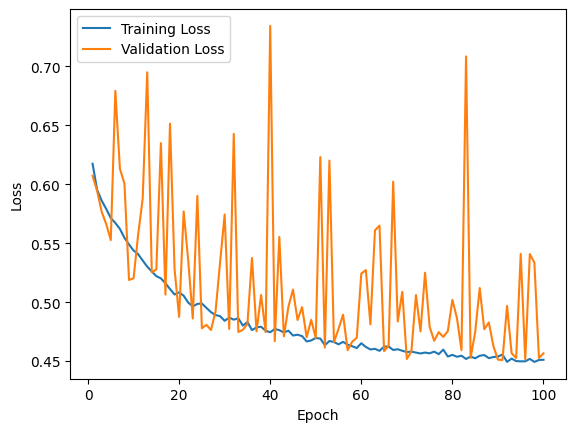

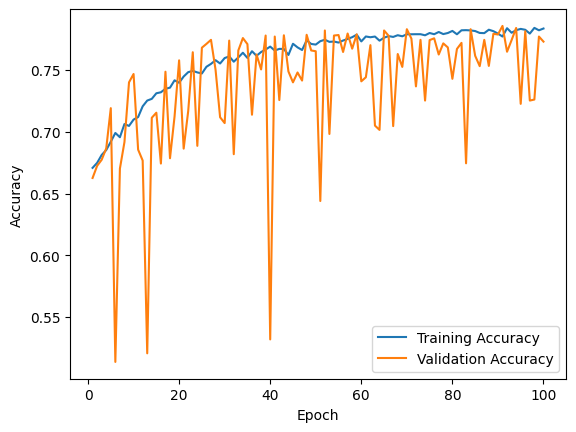

In [48]:
# Plot training and validation loss
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Plot training and validation accuracy
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Seems like training accuracy and validation accuracy follow the same curve. However, theres a lot of variance in the validation curve.

In [49]:
loss, accuracy = nn_model.evaluate(X_test, y_test)

print('Loss: {0} Accuracy: {1}'.format(loss, accuracy))

255/255 [==============================] - 0s 464us/step - loss: 0.4567 - accuracy: 0.7775
Loss: 0.45668962597846985 Accuracy: 0.7775457501411438


In [50]:
# Make predictions on the test set
probability_predictions = nn_model.predict(X_test)
class_label_predictions=[]

for i in range(0,len(y_test)):
    if probability_predictions[i] >= 0.6:
        class_label_predictions.append(1)
    else:
        class_label_predictions.append(0)


In [51]:
confusion_matrix(y_test, class_label_predictions)

array([[4593,  855],
       [ 961, 1732]])

Even after stratification, there still seems to be class imbalance as shown through the confusion matrix, as we are misclassifying many females.

The overall accuracy of the model shows that there is a statistical difference between female and male individuals based on demographic traits such as income, age, education, and hours worked per week.

In [52]:
results = pd.DataFrame({
    'Probability': probability_predictions.flatten(),
    'Predicted': class_label_predictions,
    'Actual': y_test.reset_index(drop=True)
})

# View first few rows
print(results.head(10))

   Probability  Predicted  Actual
0     0.109735          0       0
1     0.355388          0       0
2     0.120546          0       0
3     0.797021          1       1
4     0.087740          0       0
5     0.551344          0       1
6     0.590917          0       0
7     0.621990          1       1
8     0.067879          0       0
9     0.067220          0       0


In [53]:
i = 4

print("Feature values for test sample #{}:".format(i))
print(X_test.iloc[i])

print("\nPredicted probability:", probability_predictions[i][0])
print("Predicted class label:", class_label_predictions[i])
print("Actual label:", y_test.iloc[i])


Feature values for test sample #4:
income                     0.0
age                       68.0
years-of-education        16.0
hours-per-week-win        70.0
Prof-specialty             0.0
Craft-repair               0.0
Exec-managerial            0.0
Adm-clerical               0.0
Sales                      0.0
Other-service              0.0
Machine-op-inspct          0.0
Transport-moving           0.0
Handlers-cleaners          0.0
Farming-fishing            0.0
Tech-support               0.0
Protective-serv            0.0
Priv-house-serv            0.0
Armed-Forces               0.0
Private                    0.0
Self-emp-not-inc           0.0
Local-gov                  0.0
State-gov                  0.0
Self-emp-inc               0.0
Federal-gov                0.0
Without-pay                0.0
Never-worked               0.0
Married-civ-spouse         1.0
Never-married              0.0
Divorced                   0.0
Separated                  0.0
Widowed                    0.0
Marr

In [54]:
j = 70

print("Feature values for test sample #{}:".format(j))
print(X_test.iloc[j])

print("\nPredicted probability:", probability_predictions[j][0])
print("Predicted class label:", class_label_predictions[j])
print("Actual label:", y_test.iloc[j])


Feature values for test sample #70:
income                     1.0
age                       31.0
years-of-education        13.0
hours-per-week-win        80.0
Prof-specialty             0.0
Craft-repair               0.0
Exec-managerial            0.0
Adm-clerical               0.0
Sales                      1.0
Other-service              0.0
Machine-op-inspct          0.0
Transport-moving           0.0
Handlers-cleaners          0.0
Farming-fishing            0.0
Tech-support               0.0
Protective-serv            0.0
Priv-house-serv            0.0
Armed-Forces               0.0
Private                    1.0
Self-emp-not-inc           0.0
Local-gov                  0.0
State-gov                  0.0
Self-emp-inc               0.0
Federal-gov                0.0
Without-pay                0.0
Never-worked               0.0
Married-civ-spouse         1.0
Never-married              0.0
Divorced                   0.0
Separated                  0.0
Widowed                    0.0
Mar

Overall, the model functions somewhat accurately, but there is still a lot of variance and inaccuracy in predictions. This shows that there is more fine-tuning that can be done on the model, or that there is a somewhat significant gender difference in these demographic categories, but not to the extreme.

In [116]:
nn_model.save("gender_classifier_model.keras")
import zipfile

with zipfile.ZipFile("model.zip", 'w') as zipf:
    zipf.write("gender_classifier_model.keras")

In [124]:
import zipfile
from IPython.display import FileLink

model_filename = "gender_classifier_model.keras"
zip_filename = "model.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write(model_filename)

FileLink(zip_filename)


/home/ubuntu/workspace/model.zip

In [125]:
display(FileLink('DefineAndSolveMLProblem.ipynb'))

/home/ubuntu/workspace/DefineAndSolveMLProblem.ipynb